✅ XGBoost available: False
✅ sales.csv created
✅ leads.csv created
✅ Data prepared
📈 Forecast RMSE: 10.886027906055936
🎯 Lead ROC AUC: 0.5753146912224381
✅ Models saved successfully


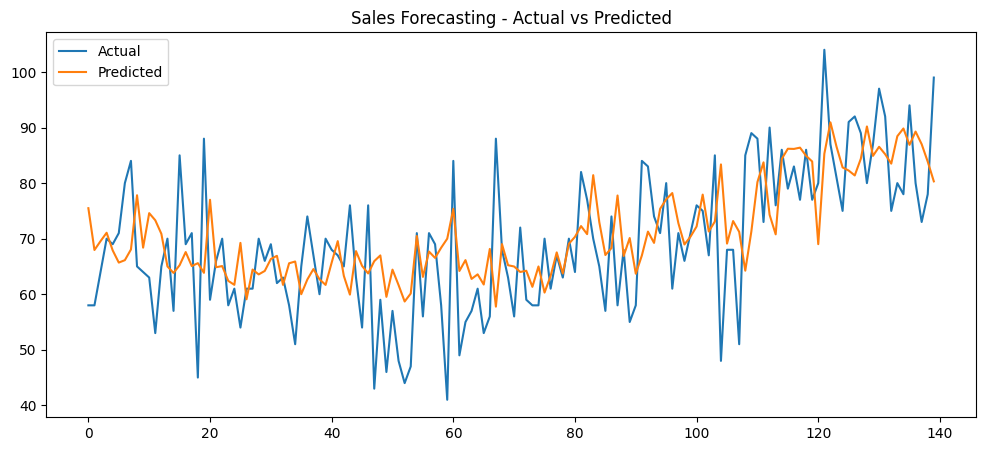

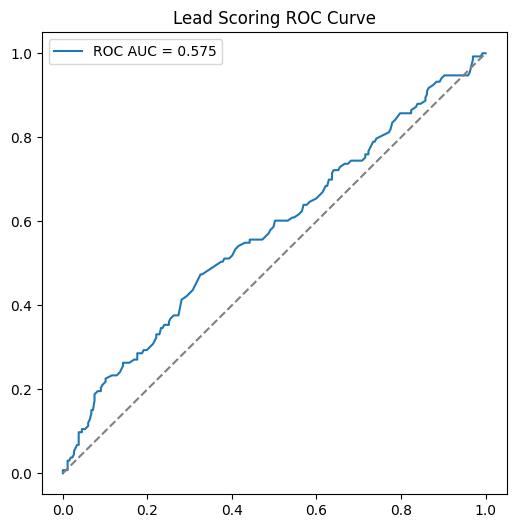

🔮 Predicted Sales for next period: 80.315
💼 Lead conversion probability: 0.17666666666666667

✅ Project completed successfully!


In [1]:
# =========================================================
# 📘 AI-Driven Sales Forecasting & Lead Scoring Project
# =========================================================
# Full end-to-end AIML project for college submission.
# ---------------------------------------------------------

# 1️⃣ Setup & Imports
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve, auc
import joblib

# Try importing XGBoost (optional, auto-switch)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
print("✅ XGBoost available:", XGBOOST_AVAILABLE)

# =========================================================
# 2️⃣ Dataset Generation
# =========================================================
np.random.seed(42)
start = datetime(2022, 1, 1)
rows = []
regions = ['North', 'South', 'East', 'West']
product_ids = [101, 102, 103]

for d in range(365 * 2):  # 2 years of data
    date = start + timedelta(days=d)
    for pid in product_ids:
        base = 20 + (pid - 100) * 5
        season = 10 * np.sin(2 * np.pi * (date.timetuple().tm_yday) / 365)
        promo = np.random.choice([0, 1], p=[0.9, 0.1])
        noise = np.random.normal(0, 5)
        units = max(0, int(base + season + 10 * promo + noise))
        rows.append({
            'date': date.strftime('%Y-%m-%d'),
            'region': np.random.choice(regions),
            'product_id': pid,
            'units_sold': units,
            'price': round(100 + pid * 2 + np.random.normal(0, 3), 2),
            'promoted': promo
        })

sales = pd.DataFrame(rows)
sales.to_csv('sales.csv', index=False)
print("✅ sales.csv created")

# Create leads dataset
n = 2000
lead_rows = []
industries = ['Tech', 'Retail', 'Finance', 'Healthcare']

for i in range(1, n + 1):
    created = start + timedelta(days=np.random.randint(0, 365 * 2))
    size = np.random.choice(['small', 'medium', 'large'], p=[0.5, 0.35, 0.15])
    source = np.random.choice(['web', 'phone', 'email', 'event'], p=[0.6, 0.1, 0.2, 0.1])
    visits = np.random.poisson(2)
    engagement = int(np.clip(np.random.normal(40 + visits * 10, 15), 0, 100))
    p_conv = 0.05 + 0.004 * engagement
    if source == 'event': p_conv += 0.08
    if size == 'large': p_conv += 0.03
    converted = np.random.rand() < p_conv
    lead_rows.append({
        'lead_id': i,
        'created_at': created.strftime('%Y-%m-%d'),
        'industry': np.random.choice(industries),
        'company_size': size,
        'lead_source': source,
        'num_site_visits': visits,
        'engagement_score': engagement,
        'converted': int(converted)
    })

leads = pd.DataFrame(lead_rows)
leads.to_csv('leads.csv', index=False)
print("✅ leads.csv created")

# =========================================================
# 3️⃣ Data Preprocessing
# =========================================================
def prepare_forecast(df_sales):
    df = df_sales.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    agg = df.groupby('date').units_sold.sum().reset_index()
    agg['dow'] = agg['date'].dt.dayofweek
    agg['month'] = agg['date'].dt.month
    for lag in [1, 7, 14, 30]:
        agg[f'lag_{lag}'] = agg['units_sold'].shift(lag)
    agg['rolling_7'] = agg['units_sold'].rolling(7).mean().shift(1)
    agg = agg.dropna()
    X = agg.drop(['date', 'units_sold'], axis=1)
    y = agg['units_sold']
    return X, y, agg


def prepare_leads(df_leads):
    df = df_leads.copy()
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['days_old'] = (pd.Timestamp.now() - df['created_at']).dt.days
    X = pd.get_dummies(df[['industry', 'company_size', 'lead_source',
                           'num_site_visits', 'engagement_score', 'days_old']],
                       drop_first=True)
    y = df['converted']
    return X, y


sales = pd.read_csv('sales.csv')
leads = pd.read_csv('leads.csv')
Xf, yf, agg = prepare_forecast(sales)
Xl, yl = prepare_leads(leads)
print("✅ Data prepared")

# =========================================================
# 4️⃣ Train Models
# =========================================================
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(Xf, yf, test_size=0.2, shuffle=False)

if XGBOOST_AVAILABLE:
    model_forecast = xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
else:
    model_forecast = RandomForestRegressor(n_estimators=200, random_state=42)

model_forecast.fit(X_train_f, y_train_f)
pred_f = model_forecast.predict(X_test_f)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test_f, pred_f))
print("📈 Forecast RMSE:", rmse)

# Lead Scoring Model
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(Xl, yl, test_size=0.2, random_state=42)

if XGBOOST_AVAILABLE:
    model_lead = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
else:
    model_lead = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)

model_lead.fit(X_train_l, y_train_l)
probs = model_lead.predict_proba(X_test_l)[:, 1]
print("🎯 Lead ROC AUC:", roc_auc_score(y_test_l, probs))

# Save models
os.makedirs('models', exist_ok=True)
joblib.dump(model_forecast, 'models/forecast_model.joblib')
joblib.dump(model_lead, 'models/lead_model.joblib')
print("✅ Models saved successfully")

# =========================================================
# 5️⃣ Evaluation & Plots
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(y_test_f.values, label='Actual')
plt.plot(pred_f, label='Predicted')
plt.title('Sales Forecasting - Actual vs Predicted')
plt.legend()
plt.show()

fpr, tpr, _ = roc_curve(y_test_l, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Lead Scoring ROC Curve')
plt.legend()
plt.show()

# =========================================================
# 6️⃣ Model Inference
# =========================================================
forecast_loaded = joblib.load('models/forecast_model.joblib')
lead_loaded = joblib.load('models/lead_model.joblib')

# Forecast example
X_example = agg.iloc[-1:].drop(['date', 'units_sold'], axis=1)
print("🔮 Predicted Sales for next period:", float(forecast_loaded.predict(X_example)[0]))

# Lead scoring example
sample = {
    'industry': 'Tech',
    'company_size': 'small',
    'lead_source': 'web',
    'num_site_visits': 3,
    'engagement_score': 70,
    'created_at': (pd.Timestamp.now() - pd.Timedelta(days=10)).strftime('%Y-%m-%d')
}

sample_df = pd.DataFrame([sample])
sample_df['created_at'] = pd.to_datetime(sample_df['created_at'])
sample_df['days_old'] = (pd.Timestamp.now() - sample_df['created_at']).dt.days
sample_X = pd.get_dummies(sample_df[['industry', 'company_size', 'lead_source',
                                     'num_site_visits', 'engagement_score', 'days_old']],
                          drop_first=True)
for c in set(Xl.columns) - set(sample_X.columns):
    sample_X[c] = 0
sample_X = sample_X[Xl.columns]
print("💼 Lead conversion probability:", float(lead_loaded.predict_proba(sample_X)[:, 1][0]))

print("\n✅ Project completed successfully!")
